<a href="https://colab.research.google.com/github/beneathmymask/-Selection-Sort--Python/blob/main/Infer%C3%AAncia_Estat%C3%ADstica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


QUESTÃO 1

Média: 1.625
Desvio-padrão: 0.183
Tamanho da amostra: 72

IC 95%:
1.582 até 1.668
Margem de erro: 0.043


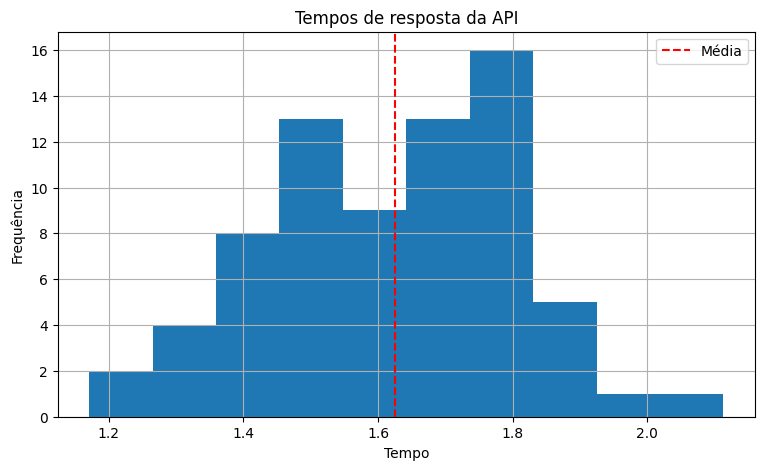


A média ficou abaixo de 1,80 segundo.

O intervalo de confiança também ficou abaixo desse valor,
então a API aparenta ter um desempenho aceitável.


QUESTÃO 2

Média ± 1 desvio: 1.442 até 1.808
Média ± 2 desvios: 1.258 até 1.992
Média ± 3 desvios: 1.075 até 2.175

Percentuais:
1 desvio: 65.28 %
2 desvios: 95.83 %
3 desvios: 100.0 %

Probabilidades:
P(X > 2.0) = 0.0204
P(X < 1.2) = 0.0102
P(1.4 < X < 1.8) = 0.7202


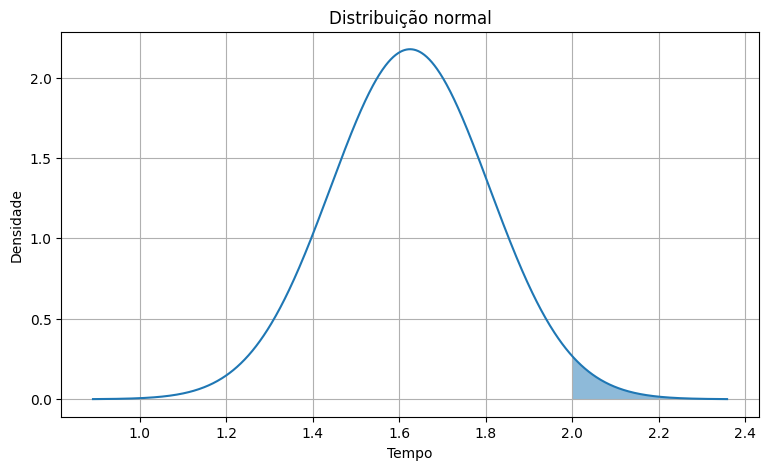


Os valores ficaram próximos da regra 68-95-99,7%.

Isso mostra que os dados seguem razoavelmente uma distribuição normal.

Mesmo assim, tempos reais de API podem ter picos e valores extremos,
então a normal é apenas uma aproximação.


QUESTÃO 3

Taxa A: 0.76
Taxa B: 0.8
Diferença: 0.04

IC 95% da diferença:
0.0072 até 0.0728

Z calculado: 2.3909
p-valor: 0.008405
Rejeitamos H0


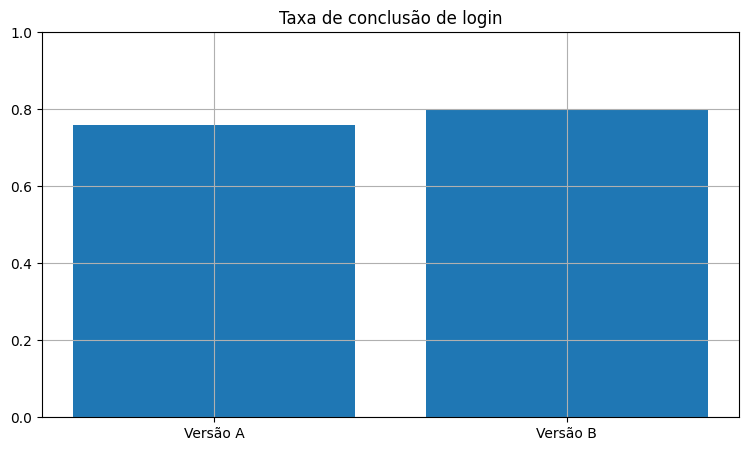


A versão B teve uma taxa de login maior.

Como o p-valor ficou abaixo de 0,05,
há evidências de que a mudança melhorou o login.

Por isso, a empresa pode considerar substituir
a versão antiga pela nova.



In [5]:
# -----------------------------------------------
# TRABALHO INDIVIDUAL - INFERÊNCIA ESTATÍSTICA
# Sistemas de Informação
# -----------------------------------------------

# Nome: Luís Henrique Martins Rocha
# Curso/Turma: BSI 3º Período
# Data: 27/05/2026

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import norm

# =====================================================
# DADOS
# =====================================================

tempos_api = np.array([
    1.690, 1.381, 1.793, 1.836, 1.171, 1.320, 1.649, 1.547,
    1.616, 1.424, 1.822, 1.799, 1.635, 1.879, 1.728, 1.422,
    1.705, 1.399, 1.822, 1.609, 1.577, 1.463, 1.901, 1.584,
    1.521, 1.539, 1.742, 1.704, 1.715, 1.719, 2.113, 1.527,
    1.502, 1.433, 1.762, 1.880, 1.594, 1.427, 1.430, 1.770,
    1.791, 1.745, 1.467, 1.673, 1.647, 1.670, 1.820, 1.671,
    1.776, 1.636, 1.686, 1.765, 1.285, 1.546, 1.512, 1.473,
    1.557, 1.964, 1.421, 1.843, 1.233, 1.543, 1.657, 1.755,
    1.784, 1.802, 1.540, 1.514, 1.817, 1.576, 1.327, 1.359
])

n_A = 1200
sucessos_A = 912

n_B = 1250
sucessos_B = 1000

# =====================================================
# QUESTÃO 1
# =====================================================

print("\nQUESTÃO 1\n")

media = np.mean(tempos_api)
desvio = np.std(tempos_api, ddof=1)
n = len(tempos_api)

print("Média:", round(media, 3))
print("Desvio-padrão:", round(desvio, 3))
print("Tamanho da amostra:", n)

# intervalo de confiança

t = stats.t.ppf(0.975, n-1)

margem = t * (desvio / np.sqrt(n))

ic_inf = media - margem
ic_sup = media + margem

print("\nIC 95%:")
print(round(ic_inf, 3), "até", round(ic_sup, 3))

print("Margem de erro:", round(margem, 3))

# gráfico

plt.hist(tempos_api, bins=10)

plt.axvline(media,
            color='red',
            linestyle='--',
            label='Média')

plt.title("Tempos de resposta da API")
plt.xlabel("Tempo")
plt.ylabel("Frequência")
plt.legend()

plt.show()

print("""
A média ficou abaixo de 1,80 segundo.

O intervalo de confiança também ficou abaixo desse valor,
então a API aparenta ter um desempenho aceitável.
""")

# =====================================================
# QUESTÃO 2
# =====================================================

print("\nQUESTÃO 2\n")

int1 = (media - desvio, media + desvio)
int2 = (media - 2*desvio, media + 2*desvio)
int3 = (media - 3*desvio, media + 3*desvio)

print("Média ± 1 desvio:", round(int1[0],3), "até", round(int1[1],3))
print("Média ± 2 desvios:", round(int2[0],3), "até", round(int2[1],3))
print("Média ± 3 desvios:", round(int3[0],3), "até", round(int3[1],3))

# percentuais

p1 = np.mean((tempos_api >= int1[0]) &
             (tempos_api <= int1[1])) * 100

p2 = np.mean((tempos_api >= int2[0]) &
             (tempos_api <= int2[1])) * 100

p3 = np.mean((tempos_api >= int3[0]) &
             (tempos_api <= int3[1])) * 100

print("\nPercentuais:")

print("1 desvio:", round(p1,2), "%")
print("2 desvios:", round(p2,2), "%")
print("3 desvios:", round(p3,2), "%")

# probabilidades

prob1 = 1 - norm.cdf(2.0, loc=media, scale=desvio)
prob2 = norm.cdf(1.2, loc=media, scale=desvio)

prob3 = (
    norm.cdf(1.8, loc=media, scale=desvio)
    - norm.cdf(1.4, loc=media, scale=desvio)
)

print("\nProbabilidades:")

print("P(X > 2.0) =", round(prob1,4))
print("P(X < 1.2) =", round(prob2,4))
print("P(1.4 < X < 1.8) =", round(prob3,4))

# gráfico normal

x = np.linspace(media - 4*desvio,
                media + 4*desvio,
                1000)

y = norm.pdf(x, media, desvio)

plt.plot(x, y)

x_fill = np.linspace(2.0,
                     media + 4*desvio,
                     300)

y_fill = norm.pdf(x_fill, media, desvio)

plt.fill_between(x_fill, y_fill, alpha=0.5)

plt.title("Distribuição normal")
plt.xlabel("Tempo")
plt.ylabel("Densidade")

plt.show()

print("""
Os valores ficaram próximos da regra 68-95-99,7%.

Isso mostra que os dados seguem razoavelmente uma distribuição normal.

Mesmo assim, tempos reais de API podem ter picos e valores extremos,
então a normal é apenas uma aproximação.
""")

# =====================================================
# QUESTÃO 3
# =====================================================

print("\nQUESTÃO 3\n")

pA = sucessos_A / n_A
pB = sucessos_B / n_B

print("Taxa A:", round(pA,4))
print("Taxa B:", round(pB,4))

dif = pB - pA

print("Diferença:", round(dif,4))

# intervalo de confiança

erro = np.sqrt(
    (pA * (1-pA) / n_A) +
    (pB * (1-pB) / n_B)
)

z = stats.norm.ppf(0.975)

margem = z * erro

ic_inf = dif - margem
ic_sup = dif + margem

print("\nIC 95% da diferença:")

print(round(ic_inf,4), "até", round(ic_sup,4))

# teste de hipótese

p_pool = (sucessos_A + sucessos_B) / (n_A + n_B)

erro_pool = np.sqrt(
    p_pool * (1-p_pool) *
    ((1/n_A) + (1/n_B))
)

z_calc = dif / erro_pool

p_valor = 1 - stats.norm.cdf(z_calc)

print("\nZ calculado:", round(z_calc,4))
print("p-valor:", round(p_valor,6))

if p_valor < 0.05:
    print("Rejeitamos H0")
else:
    print("Não rejeitamos H0")

# gráfico

plt.bar(["Versão A", "Versão B"],
        [pA, pB])

plt.ylim(0,1)

plt.title("Taxa de conclusão de login")

plt.show()

print("""
A versão B teve uma taxa de login maior.

Como o p-valor ficou abaixo de 0,05,
há evidências de que a mudança melhorou o login.

Por isso, a empresa pode considerar substituir
a versão antiga pela nova.
""")